# 01 - Why isn't a Poisson model enough?

If the only randomness came from sequencing, counts would be Poisson and their variance would equal their mean. Between biological replicates the expression level itself varies, so the variance grows to $\mu + \alpha\mu^2$. With three replicates per group, one gene's own counts can barely tell the two apart.

This is the runnable version of [note 01](notes/01_poisson_simulation.md) (in Korean), which explains each step. Sections 1 and 2 use NumPy's random numbers, so the Monte Carlo results come out a little different from the note, where I did those two checks in R. From section 3 on I used the same seeds as the note, so the numbers match exactly. The `assert` lines check that.

In [1]:
import numpy as np
from scipy import stats, integrate
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e"

## 1. Gene A spreads more than Poisson allows

Gene A is the running example of the series: three control and three glucose-starved replicates, size factors all 1. Under a Poisson model the variance/mean ratio is 1.

In [2]:
gene_a = {"Ctrl": np.array([100, 130, 90]), "Starvation": np.array([200, 250, 180])}
ratios = {}
for group, k in gene_a.items():
    m, v = k.mean(), k.var(ddof=1)
    ratios[group] = v / m
    print(f"{group:6s} mean {m:7.3f} | variance {v:6.1f} | variance/mean {v / m:.2f} | "
          f"Poisson SD {np.sqrt(m):.1f} vs observed SD {np.sqrt(v):.1f}")
assert round(ratios["Ctrl"], 2) == 4.06 and round(ratios["Starvation"], 2) == 6.19

Ctrl   mean 106.667 | variance  433.3 | variance/mean 4.06 | Poisson SD 10.3 vs observed SD 20.8
Starvation mean 210.000 | variance 1300.0 | variance/mean 6.19 | Poisson SD 14.5 vs observed SD 36.1


How often would three Poisson draws with the same mean spread at least this much?

In [3]:
rng = np.random.default_rng(1)
for group, k in gene_a.items():
    draws = rng.poisson(k.mean(), size=(100_000, 3))
    r = draws.var(axis=1, ddof=1) / draws.mean(axis=1)
    share = np.mean(r >= ratios[group])
    print(f"{group:6s} observed ratio {ratios[group]:.2f} | Poisson draws at least as spread: {share:.4f}")
    assert share < 0.05

Ctrl   observed ratio 4.06 | Poisson draws at least as spread: 0.0167
Starvation observed ratio 6.19 | Poisson draws at least as spread: 0.0019


## 2. A larger variance at a larger mean is not the evidence

Poisson variance also grows with the mean. What Poisson cannot produce is a variance/mean ratio above 1, and that ratio only means something within a group that shares one expected count. Pooling two pure-Poisson groups with different means already pushes it far above 1.

In [4]:
k100, k200 = rng.poisson(100, 100_000), rng.poisson(200, 100_000)
ratio = lambda k: k.var(ddof=1) / k.mean()
pooled = ratio(np.concatenate([k100, k200]))
print(f"mu = 100 only: {ratio(k100):.2f} | mu = 200 only: {ratio(k200):.2f} | pooled: {pooled:.2f}")
assert abs(ratio(k100) - 1) < 0.02 and 17 < pooled < 18.5   # theory: (150 + 50**2) / 150 = 17.67

mu = 100 only: 0.99 | mu = 200 only: 0.99 | pooled: 17.68


## 3. When the expression level varies between replicates

Let each replicate have its own rate $\Lambda_j$ with mean $\mu$ and variance $\alpha\mu^2$, and count reads as Poisson given that rate. The law of total variance gives

$$\mathrm{Var}(K) = E\{\mathrm{Var}(K\mid\Lambda)\} + \mathrm{Var}\{E(K\mid\Lambda)\} = \mu + \alpha\mu^2 .$$

The first term is counting noise, the second is biological variation. For gene A's control group with its final dispersion $\alpha = 0.053147$ (from note 03):

In [5]:
mu, alpha = 106.667, 0.053147
poisson_part, rate_part = mu, alpha * mu**2
print(f"Poisson part {poisson_part:.1f} + rate part {rate_part:.1f} = variance {poisson_part + rate_part:.1f} "
      f"(SD {np.sqrt(poisson_part + rate_part):.1f})")
print(f"SD of the rate = {np.sqrt(rate_part):.1f}, i.e. {100 * np.sqrt(alpha):.1f}% of the mean")
assert round(poisson_part + rate_part, 1) == 711.4

Poisson part 106.7 + rate part 604.7 = variance 711.4 (SD 26.7)
SD of the rate = 24.6, i.e. 23.1% of the mean


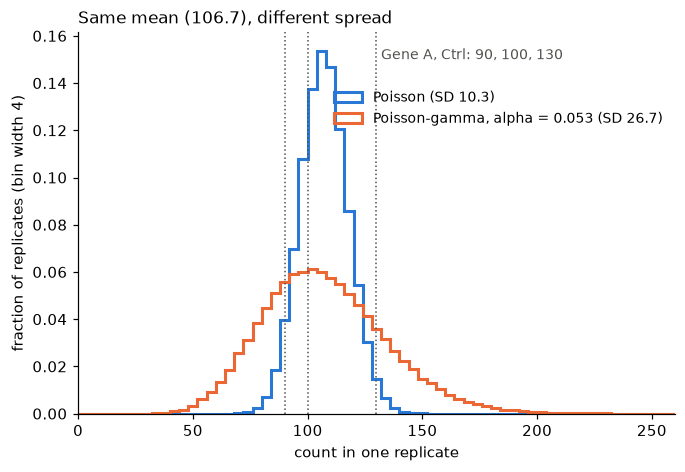

Poisson mean 106.7, SD 10.3 | Poisson-gamma mean 106.8, SD 26.7


In [6]:
rng = np.random.default_rng(11)
mu, alpha, N = 106.667, 0.053147, 200_000
pois = rng.poisson(mu, N)
gp = rng.poisson(rng.gamma(1 / alpha, alpha * mu, N))    # draw a rate, then count with it

fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.arange(0, 261, 4)
for k, color, label in [(pois, BLUE, f"Poisson (SD {pois.std():.1f})"),
                        (gp, ORANGE, f"Poisson-gamma, alpha = 0.053 (SD {gp.std():.1f})")]:
    ax.hist(k, bins=bins, weights=np.full(N, 1 / N), histtype="step", lw=2, color=color, label=label)
for x in (100, 130, 90):
    ax.axvline(x, color=MUTED, lw=1, ls=":")
ax.text(132, ax.get_ylim()[1] * 0.93, "Gene A, Ctrl: 90, 100, 130", color=MUTED, fontsize=9)
ax.set(xlabel="count in one replicate", ylabel="fraction of replicates (bin width 4)", xlim=(0, 260))
ax.set_title("Same mean (106.7), different spread", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=9, loc="upper right", bbox_to_anchor=(1, 0.88))
plt.show()
print(f"Poisson mean {pois.mean():.1f}, SD {pois.std():.1f} | Poisson-gamma mean {gp.mean():.1f}, SD {gp.std():.1f}")

Mixing a Poisson over a gamma-distributed rate gives exactly the negative binomial distribution, the model DESeq2 uses (note 02). A numerical check: integrate the mixture and compare it with SciPy's negative binomial.

In [7]:
mu, a = 30, 0.2
nb = stats.nbinom(1 / a, 1 / (1 + a * mu))               # size = 1/alpha, prob = 1/(1 + alpha*mu)
gaps = []
for k in (5, 20, 30, 60):
    f = lambda lam: stats.poisson.pmf(k, lam) * stats.gamma.pdf(lam, 1 / a, scale=a * mu)
    mix = integrate.quad(f, 0, np.inf)[0]
    gaps.append(abs(mix - nb.pmf(k)))
    print(f"k = {k:2d}  mixture integral = {mix:.6f}  nbinom.pmf = {nb.pmf(k):.6f}")
assert max(gaps) < 1e-8

k =  5  mixture integral = 0.003469  nbinom.pmf = 0.003469
k = 20  mixture integral = 0.028970  nbinom.pmf = 0.028970
k = 30  mixture integral = 0.027064  nbinom.pmf = 0.027064
k = 60  mixture integral = 0.003637  nbinom.pmf = 0.003637


## 4. Obvious with many replicates, hidden with three

With 100,000 draws the variance/mean ratio separates Poisson from overdispersed counts at once, and the moment estimate $\hat\alpha = (S^2 - \bar K)/\bar K^2$ recovers the true $\alpha$.

In [8]:
rng = np.random.default_rng(1)
def gamma_poisson(mu, alpha, size):
    return rng.poisson(rng.gamma(shape=1 / alpha, scale=alpha * mu, size=size))

n = 100_000
for label, true_a, k in [("Poisson", 0.0, rng.poisson(100, n)),
                         ("GP a=0.05", 0.05, gamma_poisson(100, 0.05, n)),
                         ("GP a=0.20", 0.20, gamma_poisson(100, 0.20, n))]:
    m, v = k.mean(), k.var(ddof=1)
    print(f"{label:10s} mean={m:7.2f} var={v:8.2f} var/mean={v / m:6.3f} (var-mean)/mean^2={(v - m) / m**2:7.4f}")
    assert abs((v - m) / m**2 - true_a) < 0.002

Poisson    mean=  99.97 var=   99.61 var/mean= 0.996 (var-mean)/mean^2=-0.0000
GP a=0.05  mean=  99.97 var=  595.97 var/mean= 5.961 (var-mean)/mean^2= 0.0496
GP a=0.20  mean= 100.01 var= 2088.14 var/mean=20.879 (var-mean)/mean^2= 0.1988


Real experiments have three to six replicates per group. Repeat the comparison 20,000 times with $n$ = 3, 6 and 30 replicates at $\mu = 100$ and look at where the sample variance lands.

In [9]:
rng = np.random.default_rng(2)
reps, mu, a = 20_000, 100, 0.05
q = [2.5, 25, 50, 75, 97.5]
below = {}
for n in (3, 6, 30):
    P  = rng.poisson(mu, (reps, n))
    GP = rng.poisson(rng.gamma(1 / a, a * mu, (reps, n)))
    for label, K in (("Poisson", P), ("GP a=0.05", GP)):
        m, s2 = K.mean(1), K.var(1, ddof=1)
        below[n, label] = np.mean(s2 < m)
        print(f"n={n:2d} {label:9s} s2 quantiles={np.percentile(s2, q).round(0)} "
              f"s2/m={np.percentile(s2 / m, q).round(2)} P(s2<m)={below[n, label]:.3f}")
assert round(below[3, "GP a=0.05"], 3) == 0.156 and round(below[3, "Poisson"], 3) == 0.626

n= 3 Poisson   s2 quantiles=[  2.  30.  70. 140. 376.] s2/m=[0.02 0.3  0.71 1.4  3.77] P(s2<m)=0.626
n= 3 GP a=0.05 s2 quantiles=[  13.  165.  401.  812. 2305.] s2/m=[ 0.14  1.69  4.07  8.09 21.66] P(s2<m)=0.156
n= 6 Poisson   s2 quantiles=[ 17.  54.  87. 133. 254.] s2/m=[0.17 0.54 0.87 1.32 2.54] P(s2<m)=0.583
n= 6 GP a=0.05 s2 quantiles=[  96.  311.  509.  786. 1605.] s2/m=[ 1.01  3.18  5.15  7.86 15.32] P(s2<m)=0.025
n=30 Poisson   s2 quantiles=[ 55.  81.  98. 117. 157.] s2/m=[0.55 0.81 0.98 1.17 1.57] P(s2<m)=0.533
n=30 GP a=0.05 s2 quantiles=[325. 480. 581. 700. 981.] s2/m=[3.31 4.84 5.82 6.96 9.61] P(s2<m)=0.000


With three replicates, 15.6% of the overdispersed genes (true variance six times the mean) still show a sample variance below the mean, while 37% of the pure Poisson genes show one above it. Only around ten to twelve replicates separate the two 95% ranges. Across many genes at once the picture looks like this:

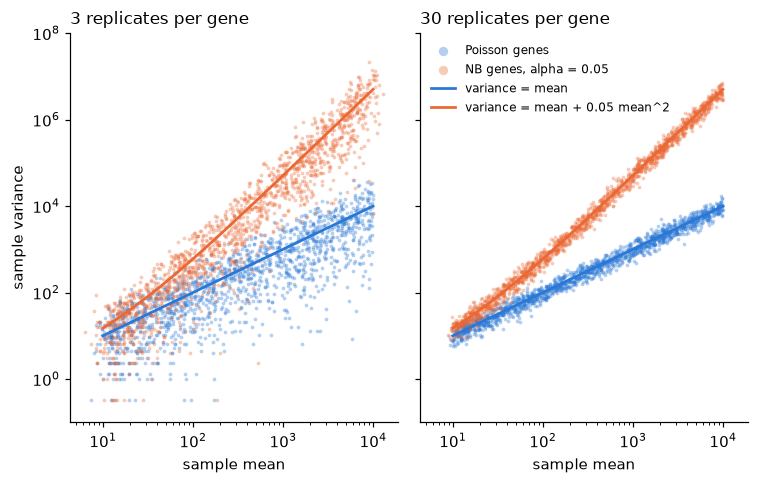

In [10]:
rng = np.random.default_rng(12)
G, alpha = 1500, 0.05
mu = np.exp(rng.uniform(np.log(10), np.log(10_000), G))
grid = np.geomspace(10, 10_000, 100)

fig, axes = plt.subplots(1, 2, figsize=(7, 4.5), sharex=True, sharey=True)
for ax, n in zip(axes, (3, 30)):
    P = rng.poisson(mu[:, None], (G, n))
    NB = rng.poisson(rng.gamma(1 / alpha, alpha * mu[:, None], (G, n)))
    for K, color, label in [(P, BLUE, "Poisson genes"), (NB, ORANGE, "NB genes, alpha = 0.05")]:
        m, s2 = K.mean(1), K.var(1, ddof=1)
        keep = s2 > 0                                     # log axes: drop zero variances
        ax.scatter(m[keep], s2[keep], s=6, alpha=0.35, color=color, lw=0, label=label)
    ax.plot(grid, grid, color=BLUE, lw=1.8, label="variance = mean")
    ax.plot(grid, grid + alpha * grid**2, color=ORANGE, lw=1.8, label="variance = mean + 0.05 mean^2")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_title(f"{n} replicates per gene", loc="left", fontsize=11)
    ax.set_xlabel("sample mean")
axes[0].set_ylabel("sample variance")
axes[0].set_ylim(1e-1, 1e8)
axes[1].legend(frameon=False, fontsize=8, loc="upper left", markerscale=2.5)
fig.tight_layout()
plt.show()

## Summary

- Counting noise alone gives Poisson counts with variance equal to the mean. For gene A's controls that is a variance of 106.7, but the three replicates vary about four times as much.
- The test for overdispersion is whether variance/mean exceeds 1 around each sample's own expected count, not whether variance rises with the mean.
- A rate that varies between replicates gives $\mathrm{Var}(K) = \mu + \alpha\mu^2$, and a gamma-distributed rate gives the negative binomial.
- Three to six replicates are too few to judge one gene's overdispersion from its own counts. That is why DESeq2 borrows information across genes (note 03).

Next: [02_negative_binomial.ipynb](02_negative_binomial.ipynb).